# NFL EPA Prediction: Expected Points Added Analysis

EPA (Expected Points Added) is an advanced NFL statistic that measures how much a single play changes a team's expected point total. Every game situation (down, distance, and field position) carries an expected point value based on historical outcomes. EPA is the difference between the expected points before and after the play.

For example, if a team is on 3rd down with 4 yards to go and gains 5 yards for a first down, that play has a positive EPA because it significantly improved the team's scoring outlook. Conversely, if a team is on 3rd and 10 and only gains 2 yards, that play has a negative EPA; the situation got worse.

This statistic is vital for measuring both offensive and defensive efficiency. The 2025-2026 Super Bowl champions, the Seattle Seahawks, had a historic defense with an EPA per play allowed of -0.12 to -0.134, a key metric that can truly define a team's greatness.

In [1]:
# --- Standard Libraries ---
import pandas as pd
import numpy as np

# --- NFL Data ---
import nfl_data_py as nfl

# --- Database ---
from sqlalchemy import create_engine

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --- Machine Learning ---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb

# --- Neural Network ---
import tensorflow as tf
from tensorflow import keras

# --- Explainability ---
import shap

# --- Utilities ---
import warnings
warnings.filterwarnings("ignore")

print("All imports successful!")

All imports successful!


In [2]:
engine = create_engine("sqlite:///../data/nfl_pbp.db")
pbp = nfl.import_pbp_data([2022, 2023, 2024, 2025])
pbp.to_sql("nfl_pbp", con=engine, if_exists='replace', index=False)
print(f"Loaded {len(pbp)} rows into SQLite")

2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.
Loaded 197362 rows into SQLite


In [3]:
df = pd.read_sql("SELECT * FROM nfl_pbp", con=engine)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 197362, Columns: 397


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,89.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,1.0,ANGLE,ZONE_COVERAGE,COVER_2,NaN,NaN,NaN,NaN,NaN,NaN
4,115.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Section 2: Exploratory Data Analysis

Before building any models, we need to understand the data. EDA helps us spot distributions, outliers, and relationships that will shape our modeling decisions. We'll look at how EPA is distributed across plays, which play types generate the most value, how teams compare, and take a closer look at the Pittsburgh Steelers.


In [4]:
df_plays = pd.read_sql("SELECT * FROM nfl_pbp WHERE play_type IN ('pass', 'run')", con=engine)
px.histogram(df_plays, x='epa', nbins=100, title='EPA Distribution per Play',
             labels={'epa': 'Expected Points Added'})

In [5]:
avg_epa = df_plays.groupby('play_type')['epa'].mean().reset_index()

fig = px.bar(avg_epa, x='play_type', y='epa', title='Average EPA per Play Type',
             labels={'epa': 'Expected Points Added'},
             color='play_type')
fig.show()

In [6]:
avg_team_epa = df_plays.groupby('posteam')['epa'].mean().reset_index()
avg_team_epa = avg_team_epa.sort_values('epa', ascending=False)

fig = px.bar(avg_team_epa, x='posteam', y='epa',
             title='Average Offensive EPA per Play by Team (2022-2025)',
             labels={'posteam': 'Team', 'epa': 'Average EPA'},
             color='epa',
             color_continuous_scale='RdYlGn')
fig.show()


In [7]:
df_pit = df_plays[df_plays['posteam'] == 'PIT']
pit_by_season = df_pit.groupby('season')['epa'].mean().reset_index()

fig = px.line(pit_by_season, x='season', y='epa',
              title='Pittsburgh Steelers Average EPA per Play by Season',
              labels={'season': 'Season', 'epa': 'Average EPA'},
              markers=True)
fig.show()


## Section 3: Feature Engineering

Before we continue into modeling we first need to identify which columns from our dataset are necessary to train models to predict EPA, these are called features. This data must also be cleaned, ensuring that data types are accurate and null values are accounted for. Finally we will define target values and lay the groundwork for a pipeline for the models to train on.

In [8]:
features = ["down", "ydstogo", "yardline_100", "score_differential", "wp", "half_seconds_remaining", "play_type"]

df_model = df_plays[features + ['epa']].dropna()

print("Shape of df_model: ", df_model.shape)
print("Data types of df_model: ", df_model.dtypes)

Shape of df_model:  (140184, 8)
Data types of df_model:  down                      float64
ydstogo                   float64
yardline_100              float64
score_differential        float64
wp                        float64
half_seconds_remaining    float64
play_type                     str
epa                       float64
dtype: object


In [9]:
y_reg = df_model['epa']
y_clf = (df_model['epa'] > 0).astype(int)
X = df_model.drop('epa', axis=1)

print(y_clf.value_counts())


epa
0    79105
1    61079
Name: count, dtype: int64


In [10]:
numeric_features = ['down', 'ydstogo', 'yardline_100', 'score_differential', 'wp', 'half_seconds_remaining']
categorical_features = ['play_type']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

## Section 4: Regression Models

In this section we will attempt to predict the actual EPA value of a play using regression models. Regression is a supervised learning technique that predicts a continuous numeric outputm, in this case the EPA value of a given play. We will compare five models: Linear Regression, Ridge, Lasso, Random Forest, and XGBoost, starting simple and increasing in complexity. Each model will be evaluated using RMSE (Root Mean Squared Error) and R-squared to measure prediction accuracy and explanatory power.


In [11]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_lr.fit(X_train, y_train_reg)
y_pred_lr = pipe_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
r2_lr = r2_score(y_test_reg, y_pred_lr)

print(f"Linear Regression -- RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")


Linear Regression -- RMSE: 1.3646, R2: 0.0018


In [12]:
pipe_r = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

pipe_r.fit(X_train, y_train_reg)
y_pred_r = pipe_r.predict(X_test)

rmse_r = np.sqrt(mean_squared_error(y_test_reg, y_pred_r))
r2_r = r2_score(y_test_reg, y_pred_r)

print(f"Ridge-- RMSE: {rmse_r:.4f}, R2: {r2_r:.4f}")


Ridge-- RMSE: 1.3646, R2: 0.0018


In [13]:
pipe_l = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

pipe_l.fit(X_train, y_train_reg)
y_pred_l = pipe_l.predict(X_test)

rmse_l = np.sqrt(mean_squared_error(y_test_reg, y_pred_l))
r2_l = r2_score(y_test_reg, y_pred_l)

print(f"Lasso -- RMSE: {rmse_l:.4f}, R2: {r2_l:.4f}")


Lasso -- RMSE: 1.3659, R2: -0.0001


In [14]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train_reg)
y_pred_rf = pipe_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
r2_rf = r2_score(y_test_reg, y_pred_rf)

print(f"Random Forest -- RMSE: {rmse_rf:.4f}, R2: {r2_rf:.4f}")


Random Forest -- RMSE: 1.4164, R2: -0.0753


In [15]:
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity = 0))
])

pipe_xgb.fit(X_train, y_train_reg)
y_pred_xgb = pipe_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
r2_xgb = r2_score(y_test_reg, y_pred_xgb)

print(f"XGBoost -- RMSE: {rmse_xgb:.4f}, R2: {r2_xgb:.4f}")


XGBoost -- RMSE: 1.3715, R2: -0.0082


In [16]:
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_r, rmse_l, rmse_rf, rmse_xgb],
    'R2': [r2_lr, r2_r, r2_l, r2_rf, r2_xgb]
}).sort_values('RMSE')

reg_results


,Model,RMSE,R2
1,Ridge,1.364647,0.001783
0,Linear Regression,1.364647,0.001783
2,Lasso,1.365910,-0.000065
4,XGBoost,1.371474,-0.008228
3,Random Forest,1.416363,-0.075308


## Regression Results and Takeaway

All five regression models produced R-squared values near zero, meaning none of them could meaningfully explain the variance in EPA. Linear Regression and Ridge tied for the best performance with an RMSE of 1.365 and R-squared of 0.0018, while Random Forest was the worst despite being the most complex model.

This result is consistent across the board and points to a fundamental limitation of the data rather than the models. Regression requires predicting the exact EPA value of a play -- not just the direction, but the magnitude. That is an extremely difficult task when working exclusively with pre-snap features. A 3rd and 4 from the opponent's 20-yard line might result in a touchdown, an incompletion, or a sack depending entirely on execution after the snap. No pre-snap feature can capture that.

The fact that simpler models matched or outperformed complex ones like Random Forest and XGBoost is telling. When signal is this weak, adding model complexity only creates more opportunity to overfit to noise. The honest conclusion is that predicting exact EPA from game situation alone is not a tractable problem with this feature set -- which makes the classification framing in Section 5 a more appropriate and revealing approach.


## Section 5: Classification Models

Where regression struggled to predict the exact EPA value of a play, classification asks a simpler and more tractable question: will this play have a positive or negative EPA? We will train six models -- Logistic Regression, Random Forest, XGBoost, SVM, KNN, and a Neural Network -- and evaluate each on accuracy, precision, recall, and ROC-AUC. ROC-AUC is our primary metric as it measures how well each model separates positive plays from negative ones regardless of classification threshold.


In [17]:
pipe_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_log.fit(X_train, y_train_clf)
y_pred_log = pipe_log.predict(X_test)
y_prob_log = pipe_log.predict_proba(X_test)[:, 1]

acc_log = accuracy_score(y_test_clf, y_pred_log)
prec_log = precision_score(y_test_clf, y_pred_log)
rec_log = recall_score(y_test_clf, y_pred_log)
auc_log = roc_auc_score(y_test_clf, y_prob_log)

print(f"Logistic Regression -- Acc: {acc_log:.4f}, Prec: {prec_log:.4f}, Rec: {rec_log:.4f}, AUC: {auc_log:.4f}")


Logistic Regression -- Acc: 0.5842, Prec: 0.5512, Rec: 0.2196, AUC: 0.5894


In [18]:
pipe_rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipe_rf_clf.fit(X_train, y_train_clf)
y_pred_rf_clf = pipe_rf_clf.predict(X_test)
y_prob_rf_clf = pipe_rf_clf.predict_proba(X_test)[:, 1]

acc_rf_clf = accuracy_score(y_test_clf, y_pred_rf_clf)
prec_rf_clf = precision_score(y_test_clf, y_pred_rf_clf)
rec_rf_clf = recall_score(y_test_clf, y_pred_rf_clf)
auc_rf_clf = roc_auc_score(y_test_clf, y_prob_rf_clf)

print(f"Random Forest -- Acc: {acc_rf_clf:.4f}, Prec: {prec_rf_clf:.4f}, Rec: {rec_rf_clf:.4f}, AUC: {auc_rf_clf:.4f}")


Random Forest -- Acc: 0.5687, Prec: 0.5032, Rec: 0.4084, AUC: 0.5705


In [19]:
pipe_xgb_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0))
])

pipe_xgb_clf.fit(X_train, y_train_clf)
y_pred_xgb_clf = pipe_xgb_clf.predict(X_test)
y_prob_xgb_clf = pipe_xgb_clf.predict_proba(X_test)[:, 1]

acc_xgb_clf = accuracy_score(y_test_clf, y_pred_xgb_clf)
prec_xgb_clf = precision_score(y_test_clf, y_pred_xgb_clf)
rec_xgb_clf = recall_score(y_test_clf, y_pred_xgb_clf)
auc_xgb_clf = roc_auc_score(y_test_clf, y_prob_xgb_clf)

print(f"XGBoost -- Acc: {acc_xgb_clf:.4f}, Prec: {prec_xgb_clf:.4f}, Rec: {rec_xgb_clf:.4f}, AUC: {auc_xgb_clf:.4f}")


XGBoost -- Acc: 0.5932, Prec: 0.5493, Rec: 0.3431, AUC: 0.6070


In [ ]:
#Train on a subset of the data due to computation limitations
X_train_svm = X_train.sample(n=20000, random_state=42)
y_train_svm = y_train_clf.loc[X_train_svm.index]

pipe_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(probability=True, kernel='rbf', C=1.0, random_state=42))
])

pipe_svm.fit(X_train_svm, y_train_svm)
y_pred_svm = pipe_svm.predict(X_test)
y_prob_svm = pipe_svm.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test_clf, y_pred_svm)
prec_svm = precision_score(y_test_clf, y_pred_svm)
rec_svm = recall_score(y_test_clf, y_pred_svm)
auc_svm = roc_auc_score(y_test_clf, y_prob_svm)

print(f"SVM -- Acc: {acc_svm:.4f}, Prec: {prec_svm:.4f}, Rec: {rec_svm:.4f}, AUC: {auc_svm:.4f}")


SVM -- Acc: 0.5919, Prec: 0.5692, Rec: 0.2412, AUC: 0.5962


In [ ]:
#Train on a subset of the data due to computation limitations
X_train_sample = X_train.sample(n=20000, random_state=42)
y_train_knn = y_train_clf.loc[X_train_sample.index]

pipe_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

pipe_knn.fit(X_train_sample, y_train_knn)
y_pred_knn = pipe_knn.predict(X_test)
y_prob_knn = pipe_knn.predict_proba(X_test)[:, 1]

acc_knn = accuracy_score(y_test_clf, y_pred_knn)
prec_knn = precision_score(y_test_clf, y_pred_knn)
rec_knn = recall_score(y_test_clf, y_pred_knn)
auc_knn = roc_auc_score(y_test_clf, y_prob_knn)

print(f"KNN -- Acc: {acc_knn:.4f}, Prec: {prec_knn:.4f}, Rec: {rec_knn:.4f}, AUC: {auc_knn:.4f}")


KNN -- Acc: 0.5463, Prec: 0.4740, Rec: 0.4257, AUC: 0.5451


In [24]:
# Preprocess using the already-fitted preprocessor from any pipeline above
X_train_nn = pipe_log.named_steps['preprocessor'].transform(X_train)
X_test_nn = pipe_log.named_steps['preprocessor'].transform(X_test)

# Build the network
model_nn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_nn.fit(X_train_nn, y_train_clf, epochs=10, batch_size=256, verbose=1)

y_prob_nn = model_nn.predict(X_test_nn).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

acc_nn = accuracy_score(y_test_clf, y_pred_nn)
prec_nn = precision_score(y_test_clf, y_pred_nn)
rec_nn = recall_score(y_test_clf, y_pred_nn)
auc_nn = roc_auc_score(y_test_clf, y_prob_nn)

print(f"Neural Network -- Acc: {acc_nn:.4f}, Prec: {prec_nn:.4f}, Rec: {rec_nn:.4f}, AUC: {auc_nn:.4f}")


Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 622us/step - accuracy: 0.5835 - loss: 0.6722
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - accuracy: 0.5862 - loss: 0.6693
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.5875 - loss: 0.6685
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.5879 - loss: 0.6682
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.5876 - loss: 0.6679
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.5885 - loss: 0.6678
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.5891 - loss: 0.6676
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.5896 - loss: 0.6674
Epoch 9/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.5891 - loss: 0.6672
Epoch 10/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - accuracy: 0.5902 - loss: 0.6671
877/877 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step
Neural Network -- Acc: 0.5977, Prec: 0.5617, Rec: 0.3273, AUC: 0.6096


In [25]:
clf_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM', 'KNN', 'Neural Network'],
    'Accuracy': [acc_log, acc_rf_clf, acc_xgb_clf, acc_svm, acc_knn, acc_nn],
    'Precision': [prec_log, prec_rf_clf, prec_xgb_clf, prec_svm, prec_knn, prec_nn],
    'Recall': [rec_log, rec_rf_clf, rec_xgb_clf, rec_svm, rec_knn, rec_nn],
    'ROC-AUC': [auc_log, auc_rf_clf, auc_xgb_clf, auc_svm, auc_knn, auc_nn]
}).sort_values('ROC-AUC', ascending=False)

clf_results


,Model,Accuracy,Precision,Recall,ROC-AUC
5,Neural Network,0.597675,0.561706,0.327300,0.609627
2,XGBoost,0.593180,0.549262,0.343097,0.607040
3,SVM,0.591932,0.569237,0.241155,0.596162
0,Logistic Regression,0.584192,0.551219,0.219598,0.589355
1,Random Forest,0.568748,0.503193,0.408425,0.570498
4,KNN,0.546278,0.474027,0.425703,0.545090


## Classification Results and Takeaway

The Neural Network narrowly edged XGBoost for the top spot with an ROC-AUC of 0.610, while KNN came in last at 0.545. However, the more important observation is the overall performance ceiling. The naive baseline for this problem is roughly 56% accuracy -- simply predicting "negative EPA" every play would be correct more than half the time due to class imbalance. Our best model reached 60%, which represents real but modest signal.

This is not a failure of the models. It reflects the fundamental nature of the problem: we are predicting play outcomes using only pre-snap information -- down, distance, field position, score, and win probability. What actually determines EPA is largely decided after the snap -- whether a receiver breaks a tackle, whether a defensive back slips, whether a pass is on target. These are inherently random events that no model can anticipate from game situation alone.

Pre-snap features can weakly predict the direction of EPA, but individual plays contain too much randomness for high-confidence classification. Season-level or drive-level aggregations would smooth out this noise and likely produce much stronger models. The real value here is understanding which situational factors push a play toward positive or negative territory -- which is exactly what we explore next with SHAP values.


## Section 6: Model Insights -- SHAP Values

Even when overall model accuracy is modest, we can still extract meaningful insights by asking: which features matter most to the model's decisions, and in what direction do they push predictions? SHAP (SHapley Additive exPlanations) answers exactly that. For every individual prediction, SHAP calculates how much each feature contributed, positively or negatively, to the final output. We will apply SHAP to our best tree model, XGBoost, to understand what situational factors most influence whether a play is predicted to generate positive or negative EPA.


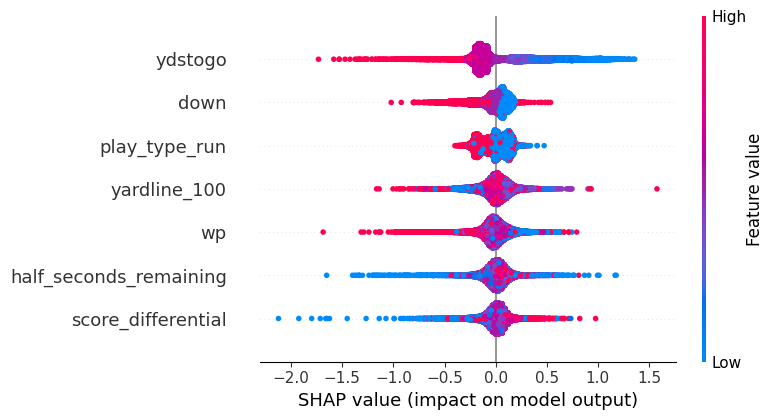

In [27]:
ohe_features = pipe_xgb_clf.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(['play_type']).tolist()
feature_names = numeric_features + ohe_features

X_test_transformed = pipe_xgb_clf.named_steps['preprocessor'].transform(X_test)
explainer = shap.TreeExplainer(pipe_xgb_clf.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)


The SHAP summary plot confirms what our model metrics suggested. Yards to go and down are the most influential features unsurprisingly, as they most directly define how much pressure a team is under on a given play. Play type (run vs pass) ranks third, reflecting the different EPA profiles of each approach. Field position, win probability, game clock, and score differential all contribute, but their SHAP values cluster tightly around zero across most plays.

This tight clustering is the visual signature of a high-noise prediction problem. No single pre-snap feature can reliably push a prediction far from the baseline, because the outcome depends overwhelmingly on what happens after the snap. SHAP has not revealed a flaw in our modeling, it has confirmed that the signal in our features is real but weak, and spread across all variables rather than concentrated in one.


## Section 7: Conclusions

### What We Built

This project built and compared 11 machine learning models across two problem framings: predicting the exact EPA value of a play (regression) and predicting whether a play would generate positive or negative EPA (classification). Data from four NFL seasons (2022-2025) was stored in SQLite, queried with SQL, preprocessed through sklearn Pipelines, and evaluated with industry-standard metrics.

### What We Found

Regression models failed to explain meaningful variance in EPA, with all five models producing R-squared values near zero. The best performer was Linear Regression, which actually outperformed more complex models like Random Forest and XGBoost. This is a strong signal that the relationship between pre-snap features and exact EPA is not learnable from game situation alone.

Classification models performed better in relative terms, with the Neural Network and XGBoost reaching ROC-AUC scores of 0.610 and 0.607 respectively. All models meaningfully outperformed the naive majority-class baseline, confirming that pre-snap context carries real but limited signal about play direction.

SHAP analysis identified yards to go and down as the most influential features, which aligns with football intuition. The tight clustering of SHAP values around zero across all features confirmed that no single situational variable dominates EPA outcomes.

### The Core Insight

Individual NFL plays are high-noise events. What happens after the snap, execution, athleticism, and chance, determines EPA far more than what the scoreboard says before it. Pre-snap features are useful for understanding tendencies at scale but are insufficient for predicting individual outcomes with confidence.

### What's Next

Future iterations of this project could explore: drive-level or season-level EPA aggregation to reduce noise, post-snap features such as yards gained and air yards, player-level features like passer rating and receiver separation, and a FastAPI deployment layer to serve predictions in real time.
